# SNL 스마일 클리닉 클립 미들폼 수요 분석
### YouTube Data API v3로 쿠팡플레이 채널 내 SNL 코너별 영상을 수집하여
### "성형외과(스마일 클리닉)" 코너의 단독 분리 수요를 다른 코너와 비교 증명

In [1]:
!pip install google-api-python-client python-dotenv sqlalchemy pymysql plotly

## 0. 환경 설정 및 라이브러리 로드

In [2]:
import os
import re
import pandas as pd
from datetime import datetime, timezone
from dotenv import load_dotenv
from googleapiclient.discovery import build
from sqlalchemy import create_engine, text
import pymysql
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
 
load_dotenv()
 
API_KEY    = os.getenv('YOUTUBE_API_KEY')
MYSQL_HOST = os.getenv('MYSQL_HOST', 'localhost')
MYSQL_USER = os.getenv('MYSQL_USER', 'root')
MYSQL_PW   = os.getenv('MYSQL_PASSWORD', '')
MYSQL_DB   = os.getenv('MYSQL_DB', 'youtube_data')
 
assert API_KEY, '.env에 YOUTUBE_API_KEY가 없습니다.'
 
print(f'API KEY : {API_KEY[:8]}...')
print(f'MySQL   : {MYSQL_USER}@{MYSQL_HOST}/{MYSQL_DB}')

API KEY : AIzaSyCf...
MySQL   : root@localhost/youtube_data


## 1. YouTube API 클라이언트 초기화

In [3]:
def build_youtube_client(api_key: str):
    try:
        client = build('youtube', 'v3', developerKey=api_key)
        print('YouTube API 클라이언트 초기화 완료')
        return client
    except Exception as e:
        print(f'[ERROR] YouTube 클라이언트 초기화 실패: {e}')
        raise
 
youtube = build_youtube_client(API_KEY)
 

YouTube API 클라이언트 초기화 완료


## 2. MySQL DB 연결

In [4]:
def create_db_engine(host: str, user: str, pw: str, db: str):
    try:
        conn = pymysql.connect(host=host, user=user, password=pw, charset='utf8mb4')
        with conn.cursor() as cur:
            cur.execute(
                f'CREATE DATABASE IF NOT EXISTS `{db}` '
                f'CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci'
            )
        conn.close()
 
        url    = f'mysql+pymysql://{user}:{pw}@{host}/{db}?charset=utf8mb4'
        engine = create_engine(url)
        with engine.connect() as c:
            c.execute(text('SELECT 1'))
        print(f'MySQL 연결 성공: {user}@{host}/{db}')
        return engine
    except Exception as e:
        print(f'[ERROR] MySQL 연결 실패: {e}')
        raise
 
engine = create_db_engine(MYSQL_HOST, MYSQL_USER, MYSQL_PW, MYSQL_DB)

MySQL 연결 성공: root@localhost/youtube_data


## 3. 쿠팡플레이 채널 전체 영상 ID 수집

In [5]:
CHANNEL_ID = 'UCjn-VbcIkAeXQKCmLJV8YwQ'   # 쿠팡플레이 공식 채널
 
def get_uploads_playlist_id(client, channel_id: str) -> str:
    try:
        res = client.channels().list(
            id=channel_id,
            part='contentDetails'
        ).execute()
        playlist_id = res['items'][0]['contentDetails']['relatedPlaylists']['uploads']
        print(f'업로드 플레이리스트 ID: {playlist_id}')
        return playlist_id
    except Exception as e:
        print(f'[ERROR] 플레이리스트 ID 조회 실패: {e}')
        raise
 
 
def get_all_video_ids(client, playlist_id: str) -> list:
    video_ids = []
    next_page_token = None
    try:
        while True:
            res = client.playlistItems().list(
                playlistId=playlist_id,
                part='contentDetails',
                maxResults=50,
                pageToken=next_page_token
            ).execute()
            for item in res.get('items', []):
                video_ids.append(item['contentDetails']['videoId'])
            next_page_token = res.get('nextPageToken')
            if not next_page_token:
                break
    except Exception as e:
        print(f'[ERROR] 영상 ID 수집 중 오류 (수집된 수: {len(video_ids)}): {e}')
    return video_ids
 
 
playlist_id = get_uploads_playlist_id(youtube, CHANNEL_ID)
video_ids   = get_all_video_ids(youtube, playlist_id)
print(f'전체 영상 수집 완료: {len(video_ids)}개')

업로드 플레이리스트 ID: UUjn-VbcIkAeXQKCmLJV8YwQ
전체 영상 수집 완료: 3159개


## 4. 영상 상세 정보 수집 및 SNL 코너 분류

In [6]:
# SNL 코너 키워드 매핑 (제목 기반 분류)
CORNER_KEYWORDS = {
    '스마일클리닉': ['성형외과', '스마일 클리닉', '스마일클리닉'],
    '위켄드 업데이트': ['위켄드 업데이트', '주말 업데이트'],
    '신상출시': ['신상출시', '신상 출시'],
    '직장의신': ['직장의신', '직장의 신'],
    '기타SNL': ['SNL', 'snl']   # 위 코너에 해당 안 되는 SNL 영상 전체
}
 
MIDDLEFORM_MIN_SEC = 5  * 60   # 5분
MIDDLEFORM_MAX_SEC = 15 * 60   # 15분
 
 
def parse_duration(iso_duration: str) -> int:
    """ISO 8601 재생시간 → 초 단위 정수"""
    if not iso_duration:
        return 0
    match = re.match(r'PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?', iso_duration)
    if not match:
        return 0
    h = int(match.group(1) or 0)
    m = int(match.group(2) or 0)
    s = int(match.group(3) or 0)
    return h * 3600 + m * 60 + s
 
 
def classify_corner(title: str) -> str:
    """영상 제목 기반 코너 분류 (우선순위: 스마일클리닉 → 위켄드 → 신상 → 직장 → 기타SNL → 비SNL)"""
    title_lower = title.lower()
    for corner, keywords in CORNER_KEYWORDS.items():
        if corner == '기타SNL':
            continue
        if any(kw in title for kw in keywords):
            return corner
    # 기타 SNL 판정
    if any(kw.lower() in title_lower for kw in CORNER_KEYWORDS['기타SNL']):
        return '기타SNL'
    return '비SNL'
 
 
def fetch_video_details(client, ids: list) -> list:
    records = []
    for i in range(0, len(ids), 50):
        chunk = ids[i:i + 50]
        try:
            res = client.videos().list(
                id   =','.join(chunk),
                part ='snippet,statistics,contentDetails'
            ).execute()
            for item in res.get('items', []):
                snippet  = item.get('snippet', {})
                stats    = item.get('statistics', {})
                content  = item.get('contentDetails', {})
 
                title        = snippet.get('title', '')
                duration_iso = content.get('duration', 'PT0S')
                duration_sec = parse_duration(duration_iso)
                view         = int(stats.get('viewCount', 0) or 0)
                like         = int(stats.get('likeCount', 0) or 0)
                comment      = int(stats.get('commentCount', 0) or 0)
 
                records.append({
                    'video_id':       item['id'],
                    'title':          title,
                    'published_at':   snippet.get('publishedAt', ''),
                    'duration':       duration_iso,
                    'duration_sec':   duration_sec,
                    'view_count':     view,
                    'like_count':     like,
                    'comment_count':  comment,
                    'like_rate':      round(like    / view * 100, 4) if view > 0 else 0.0,
                    'comment_rate':   round(comment / view * 100, 4) if view > 0 else 0.0,
                    'corner':         classify_corner(title),
                    'is_middleform':  MIDDLEFORM_MIN_SEC <= duration_sec <= MIDDLEFORM_MAX_SEC,
                    'collected_at':   datetime.now(timezone.utc).isoformat()
                })
        except Exception as e:
            print(f'[ERROR] 상세 수집 실패 (chunk {i}~{i+50}): {e}')
    return records
 
 
records = fetch_video_details(youtube, video_ids)
print(f'상세 수집 완료: {len(records)}개')
 

상세 수집 완료: 3159개


## 5. DataFrame 정리

In [7]:
def build_dataframe(records: list) -> pd.DataFrame:
    df = pd.DataFrame(records)
 
    num_cols = ['duration_sec', 'view_count', 'like_count', 'comment_count']
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
 
    float_cols = ['like_rate', 'comment_rate']
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)
 
    str_cols = ['video_id', 'title', 'published_at', 'duration', 'corner', 'collected_at']
    for col in str_cols:
        df[col] = df[col].fillna('')
 
    return df
 
 
df = build_dataframe(records)
 
print('\n코너별 영상 수:')
print(df['corner'].value_counts())
print('\n미들폼(5~15분) 영상 수:', df['is_middleform'].sum())
df.head(3)


코너별 영상 수:
corner
비SNL        2509
기타SNL        618
위켄드 업데이트      18
스마일클리닉        14
Name: count, dtype: int64

미들폼(5~15분) 영상 수: 270


,video_id,title,published_at,duration,duration_sec,view_count,like_count,comment_count,like_rate,comment_rate,corner,is_middleform,collected_at
0,35FhwcPX5do,보기만 해도 아픔 🤕 [로맨스의 절댓값],2026-05-18T11:03:00Z,PT50S,50,10207,347,10,3.3996,0.0980,비SNL,False,2026-05-19T03:49:26.546390+00:00
1,yTZ3acCwr6w,선생님 퇴학이라뇨... 우리 의주 지켜주세요 😣 [로맨스의 절댓값] 13-14화 예고편,2026-05-18T09:01:14Z,PT38S,38,7710,214,18,2.7756,0.2335,비SNL,False,2026-05-19T03:49:26.546474+00:00
2,IPIlF7mvq8o,국어 선생님의 그림 🐍 [로맨스의 절댓값],2026-05-18T09:00:32Z,PT37S,37,8407,176,5,2.0935,0.0595,비SNL,False,2026-05-19T03:49:26.546517+00:00


## 6. SNL 영상만 필터링

In [8]:
snl_df = df[df['corner'] != '비SNL'].copy()
print(f'SNL 영상 수: {len(snl_df)}개')
print(snl_df['corner'].value_counts())

SNL 영상 수: 650개
corner
기타SNL       618
위켄드 업데이트     18
스마일클리닉       14
Name: count, dtype: int64


## 7. MySQL 저장

In [9]:
def save_to_mysql(df: pd.DataFrame, engine, table: str) -> None:
    try:
        df.to_sql(
            name      = table,
            con       = engine,
            if_exists = 'replace',
            index     = False,
            chunksize = 500
        )
        with engine.connect() as conn:
            count = conn.execute(text(f'SELECT COUNT(*) FROM `{table}`')).scalar()
        print(f'저장 완료: {count}개 레코드 → {MYSQL_DB}.{table}')
    except Exception as e:
        print(f'[ERROR] MySQL 저장 실패: {e}')
        raise
 
# 전체 데이터 저장
save_to_mysql(df,     engine, table='snl_all_videos')
# SNL 필터링 데이터 저장
save_to_mysql(snl_df, engine, table='snl_corner_videos')

저장 완료: 3159개 레코드 → youtube_data.snl_all_videos
저장 완료: 650개 레코드 → youtube_data.snl_corner_videos


## 8. CSV 저장

In [10]:
OUTPUT_DIR = os.path.expanduser('~/Downloads')   # 필요 시 경로 수정
 
df.to_csv(     f'{OUTPUT_DIR}/snl_all_videos.csv',    index=False, encoding='utf-8-sig')
snl_df.to_csv( f'{OUTPUT_DIR}/snl_corner_videos.csv', index=False, encoding='utf-8-sig')
print('CSV 저장 완료')

CSV 저장 완료


## 9. 저장 결과 확인 (DB 조회)

In [11]:
corner_summary = pd.read_sql(
    '''
    SELECT
        corner,
        COUNT(*)                       AS video_count,
        ROUND(AVG(view_count))         AS avg_views,
        ROUND(AVG(like_count))         AS avg_likes,
        ROUND(AVG(like_rate),  4)      AS avg_like_rate,
        ROUND(AVG(comment_rate), 4)    AS avg_comment_rate,
        ROUND(AVG(duration_sec) / 60, 1) AS avg_duration_min
    FROM snl_corner_videos
    GROUP BY corner
    ORDER BY avg_views DESC
    ''',
    con=engine
)
display(corner_summary)
 

,corner,video_count,avg_views,avg_likes,avg_like_rate,avg_comment_rate,avg_duration_min
0,스마일클리닉,14,2214928.0,17213.0,0.8672,0.0291,2.5
1,위켄드 업데이트,18,1032778.0,12715.0,1.1384,0.0698,1.9
2,기타SNL,618,1031634.0,9195.0,0.9883,0.0928,2.4


## 10. 시각화

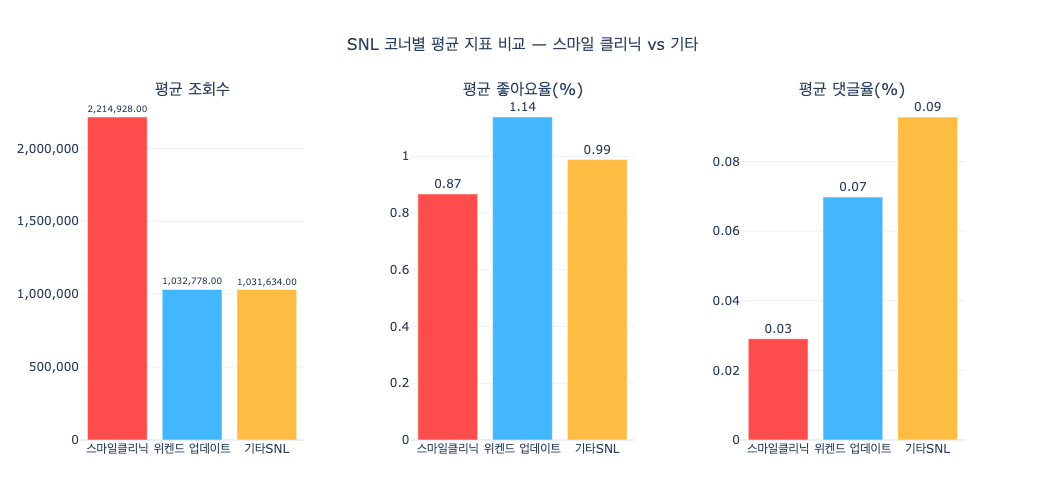

In [12]:
# ── 시각화 공통 컬러 설정 ──
COLOR_SMILE    = '#FF4D4D'   # 스마일클리닉 강조색
COLOR_OTHERS   = ['#42B6FF', '#FF7AC8', '#7CCA62', '#FFBC42']
COLOR_MAP = {
    '스마일클리닉':   COLOR_SMILE,
    '위켄드 업데이트': COLOR_OTHERS[0],
    '신상출시':       COLOR_OTHERS[1],
    '직장의신':       COLOR_OTHERS[2],
    '기타SNL':        COLOR_OTHERS[3],
}
 
corners_order = corner_summary['corner'].tolist()
bar_colors    = [COLOR_MAP.get(c, '#AAAAAA') for c in corners_order]
 
 
# ### 10-1. 코너별 평균 조회수 / 좋아요율 / 댓글율 비교
 
# In[12]:
 
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=['평균 조회수', '평균 좋아요율(%)', '평균 댓글율(%)'],
    horizontal_spacing=0.12
)
 
metrics = [
    ('avg_views',        '평균 조회수'),
    ('avg_like_rate',    '평균 좋아요율(%)'),
    ('avg_comment_rate', '평균 댓글율(%)')
]
 
for col_pos, (col_name, label) in enumerate(metrics, start=1):
    fig.add_trace(
        go.Bar(
            x=corner_summary['corner'],
            y=corner_summary[col_name],
            marker_color=bar_colors,
            text=corner_summary[col_name].apply(lambda v: f'{v:,.2f}'),
            textposition='outside',
            showlegend=False,
        ),
        row=1, col=col_pos
    )
 
fig.update_layout(
    title_text='SNL 코너별 평균 지표 비교 — 스마일 클리닉 vs 기타',
    title_x=0.5,
    title_font_size=16,
    height=500,
    template='plotly_white',
    margin=dict(t=100, b=60)
)
fig.update_yaxes(tickformat=',')
fig.show()

## 10-2. 스마일 클리닉 vs 나머지 SNL 전체 평균 비교 (2-group)

,group,video_count,avg_views,avg_like_rate,avg_comment_rate
0,기타 SNL 코너,636,1.031667e+06,0.9926,0.0922
1,스마일 클리닉,14,2.214928e+06,0.8672,0.0291


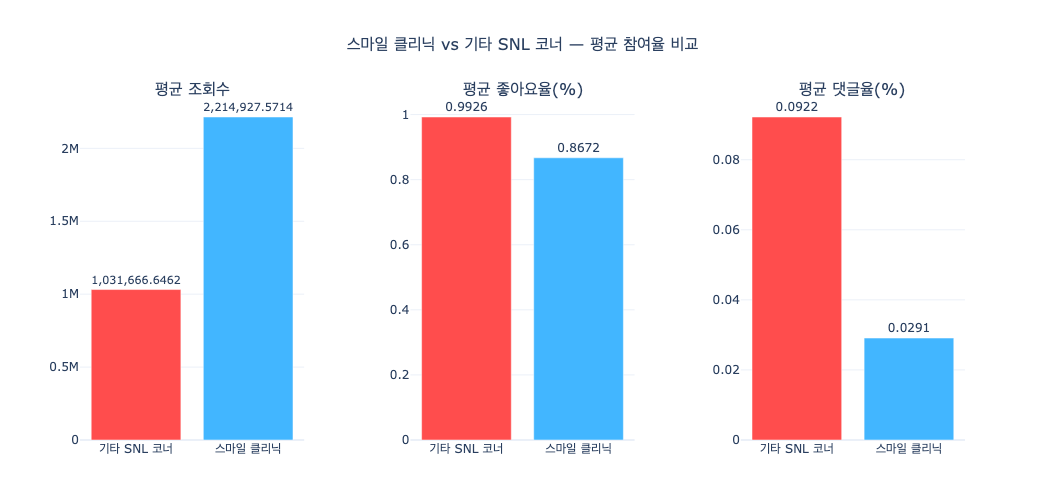

In [13]:
snl_df['group'] = snl_df['corner'].apply(
    lambda x: '스마일 클리닉' if x == '스마일클리닉' else '기타 SNL 코너'
)
 
group_summary = snl_df.groupby('group').agg(
    video_count   =('video_id',     'count'),
    avg_views     =('view_count',   'mean'),
    avg_like_rate =('like_rate',    'mean'),
    avg_comment_rate=('comment_rate', 'mean'),
).reset_index().round(4)
 
display(group_summary)
 
fig2 = make_subplots(
    rows=1, cols=3,
    subplot_titles=['평균 조회수', '평균 좋아요율(%)', '평균 댓글율(%)'],
    horizontal_spacing=0.12
)
 
group_colors = [COLOR_SMILE, '#42B6FF']
 
for col_pos, col_name in enumerate(['avg_views', 'avg_like_rate', 'avg_comment_rate'], start=1):
    fig2.add_trace(
        go.Bar(
            x=group_summary['group'],
            y=group_summary[col_name],
            marker_color=group_colors,
            text=group_summary[col_name].apply(lambda v: f'{v:,.4f}'),
            textposition='outside',
            showlegend=False,
        ),
        row=1, col=col_pos
    )
 
fig2.update_layout(
    title_text='스마일 클리닉 vs 기타 SNL 코너 — 평균 참여율 비교',
    title_x=0.5,
    title_font_size=16,
    height=500,
    template='plotly_white',
    margin=dict(t=100, b=60)
)
fig2.show()
 

## 10-3. 미들폼(5~15분) 영역에서의 스마일 클리닉 성과

미들폼 영상 수: 27개
corner
기타SNL    27
Name: count, dtype: int64


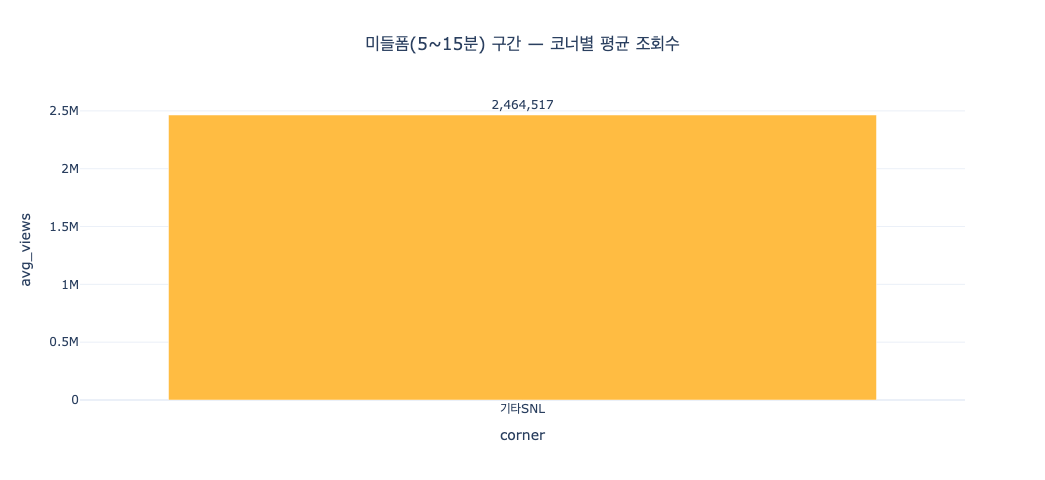

In [14]:
mid_df = snl_df[snl_df['is_middleform'] == True].copy()
print(f'미들폼 영상 수: {len(mid_df)}개')
print(mid_df['corner'].value_counts())
 
mid_group = mid_df.groupby('corner').agg(
    video_count     =('video_id',     'count'),
    avg_views       =('view_count',   'mean'),
    avg_like_rate   =('like_rate',    'mean'),
    avg_comment_rate=('comment_rate', 'mean'),
).reset_index().sort_values('avg_views', ascending=False).round(4)
 
fig3 = px.bar(
    mid_group,
    x='corner',
    y='avg_views',
    color='corner',
    color_discrete_map=COLOR_MAP,
    text='avg_views',
    title='미들폼(5~15분) 구간 — 코너별 평균 조회수',
    template='plotly_white',
    height=480
)
fig3.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig3.update_layout(title_x=0.5, showlegend=False)
fig3.show()

## 10-4. 스마일 클리닉 영상 조회수 분포 (scatter)

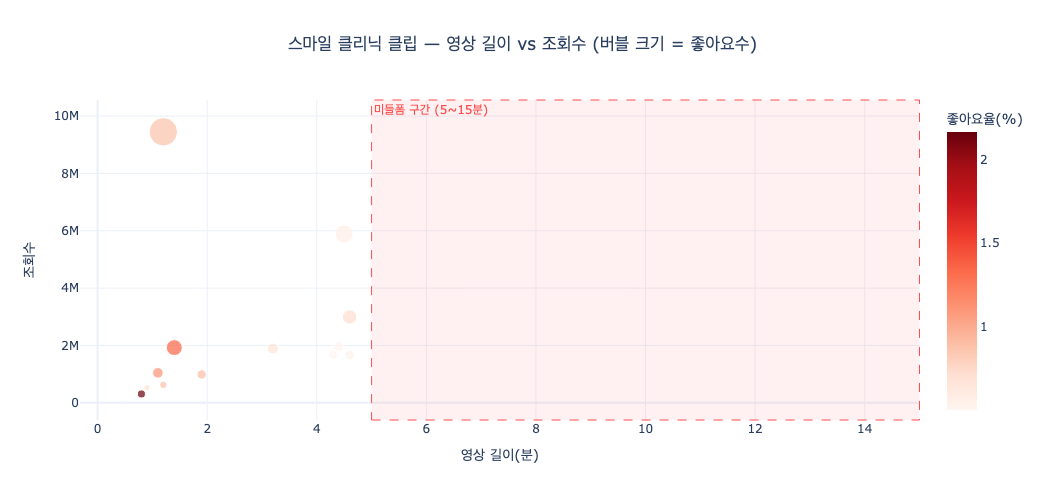

In [15]:
smile_df = snl_df[snl_df['corner'] == '스마일클리닉'].copy()
smile_df['duration_min'] = (smile_df['duration_sec'] / 60).round(1)
 
fig4 = px.scatter(
    smile_df,
    x='duration_min',
    y='view_count',
    size='like_count',
    color='like_rate',
    hover_name='title',
    color_continuous_scale='Reds',
    title='스마일 클리닉 클립 — 영상 길이 vs 조회수 (버블 크기 = 좋아요수)',
    labels={'duration_min': '영상 길이(분)', 'view_count': '조회수', 'like_rate': '좋아요율(%)'},
    template='plotly_white',
    height=500
)
 
# 미들폼 구간 음영 표시
fig4.add_vrect(
    x0=5, x1=15,
    fillcolor='rgba(255,77,77,0.08)',
    line_width=1,
    line_dash='dash',
    line_color='#FF4D4D',
    annotation_text='미들폼 구간 (5~15분)',
    annotation_position='top left',
    annotation_font_color='#FF4D4D'
)
 
fig4.update_layout(title_x=0.5)
fig4.show()

## 10-5. 코너별 업로드 비중 파이차트

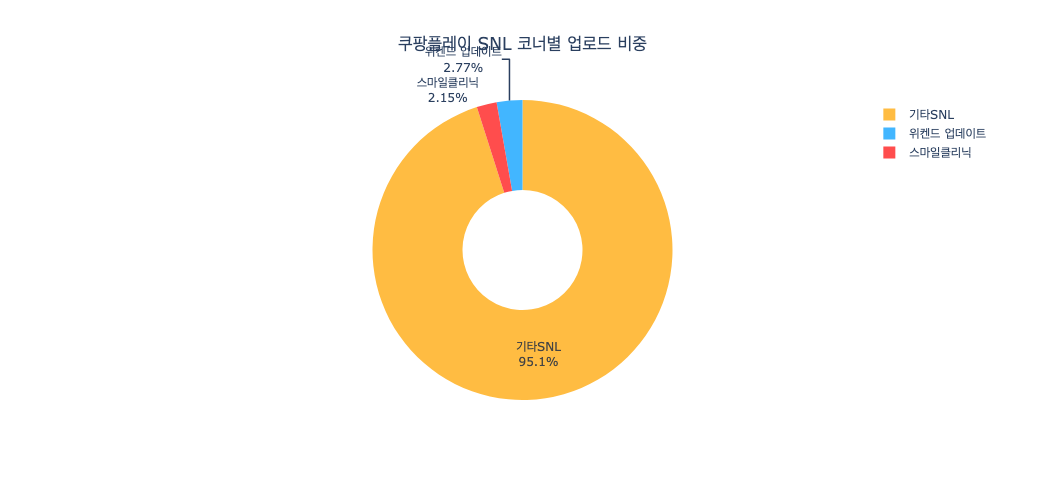

In [16]:
corner_counts = snl_df['corner'].value_counts().reset_index()
corner_counts.columns = ['corner', 'count']
pie_colors = [COLOR_MAP.get(c, '#AAAAAA') for c in corner_counts['corner']]
 
fig5 = go.Figure(go.Pie(
    labels=corner_counts['corner'],
    values=corner_counts['count'],
    marker=dict(colors=pie_colors),
    textinfo='label+percent',
    hole=0.4
))
fig5.update_layout(
    title='쿠팡플레이 SNL 코너별 업로드 비중',
    template='plotly_white',
    title_x=0.5,
    height=480
)
fig5.show()

## 10-6. TOP 10 스마일 클리닉 영상 조회수 순위

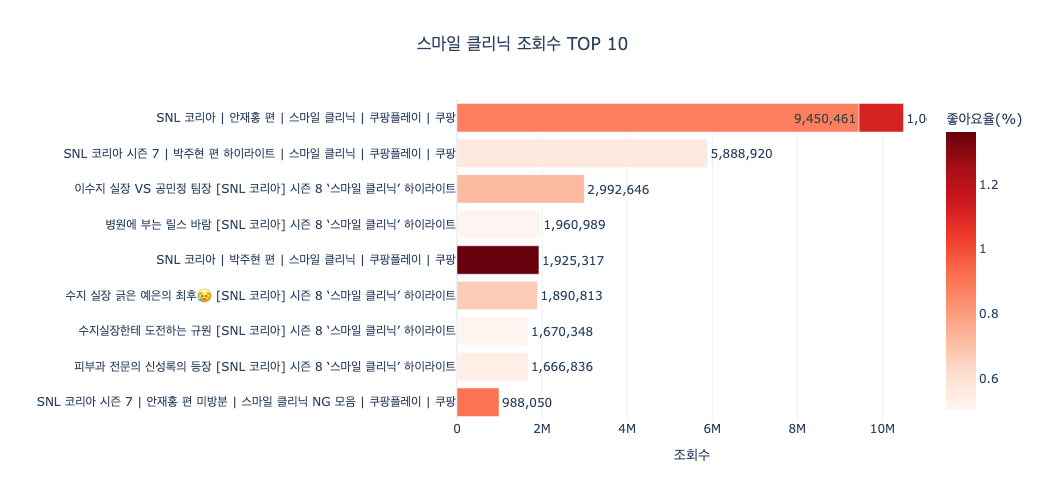

In [17]:
top10_smile = smile_df.sort_values('view_count', ascending=False).head(10)
 
fig6 = px.bar(
    top10_smile,
    x='view_count',
    y='title',
    orientation='h',
    color='like_rate',
    color_continuous_scale='Reds',
    text='view_count',
    title='스마일 클리닉 조회수 TOP 10',
    labels={'view_count': '조회수', 'title': '', 'like_rate': '좋아요율(%)'},
    template='plotly_white',
    height=500
)
fig6.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig6.update_layout(title_x=0.5, yaxis={'categoryorder': 'total ascending'})
fig6.show()